In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Dataset ["Crop Recommendation"](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset):
- N - relación del contenido de nitrógeno en el suelo

- P - relación del contenido de fósforo en el suelo

- K - relación del contenido de potasio en el suelo

- temperature - temperatura en grados Celsius

- humidity - humedad relativa en %

- ph - valor de ph del suelo

- rainfall - precipitaciones en mm

- label - Tipo de cultivo

In [58]:
data = pd.read_csv('./data/crop_recommendation.csv')
data

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


### EDA

In [59]:
data['label'].unique()

<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

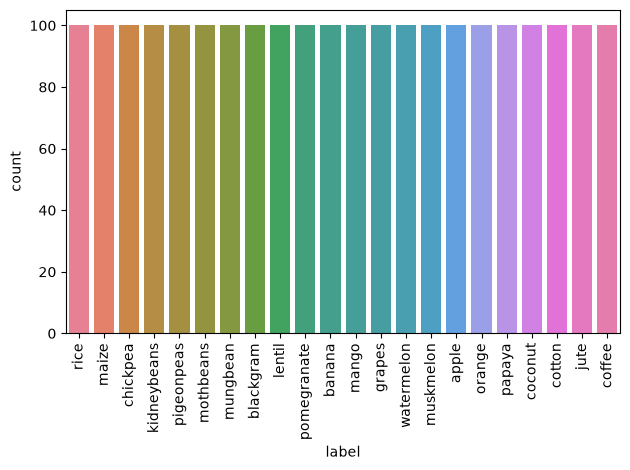

In [60]:
plt.figure(layout='tight')
sns.countplot(data=data, x='label', hue='label')
plt.xticks(rotation=90)
plt.show()

In [61]:
print(data['label'].value_counts())

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [62]:
num_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

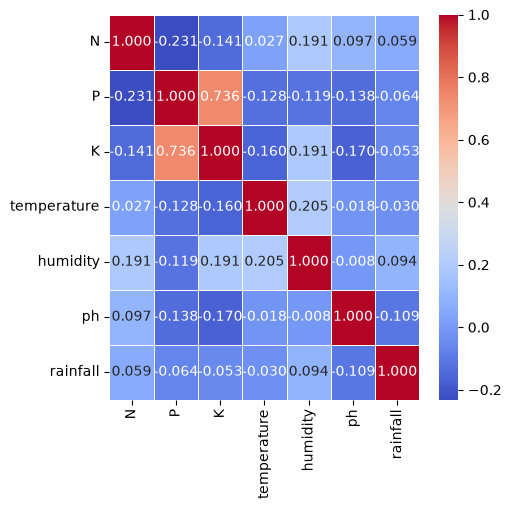

In [63]:
# Confusion Matrix
plt.figure(figsize=(5,5))
sns.heatmap(data=data[num_features].corr(), annot=True, cmap='coolwarm', linewidths=.5, fmt=".3f")
plt.show()

/tmp/ipykernel_34978/3403982195.py:2: UserWarning: 
The palette list has fewer values (20) than needed (22) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=data, x='P', y='N', hue='label', palette=sns.color_palette("tab20", 20))


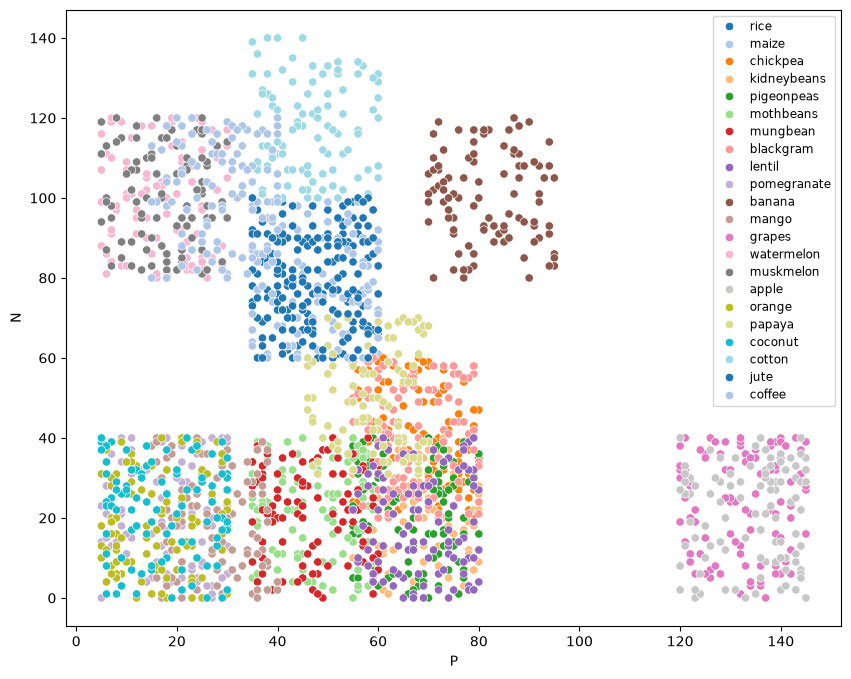

In [64]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=data, x='P', y='N', hue='label', palette=sns.color_palette("tab20", 20))
plt.legend(fontsize="small", labelspacing=0.4, borderpad=0.4)
plt.show()

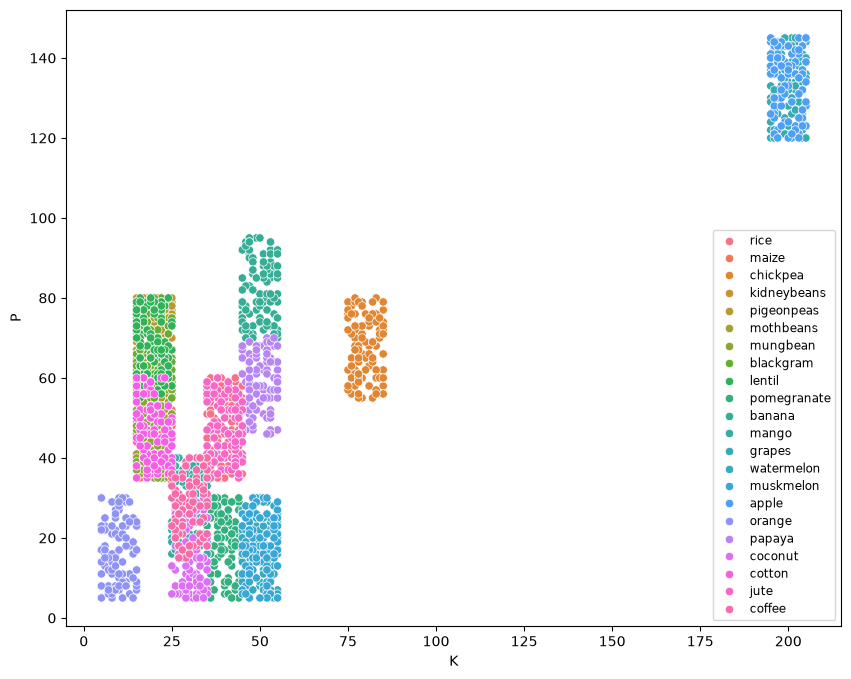

In [65]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=data, x='K', y='P', hue='label')
plt.legend(fontsize="small", labelspacing=0.4, borderpad=0.4)
plt.show()

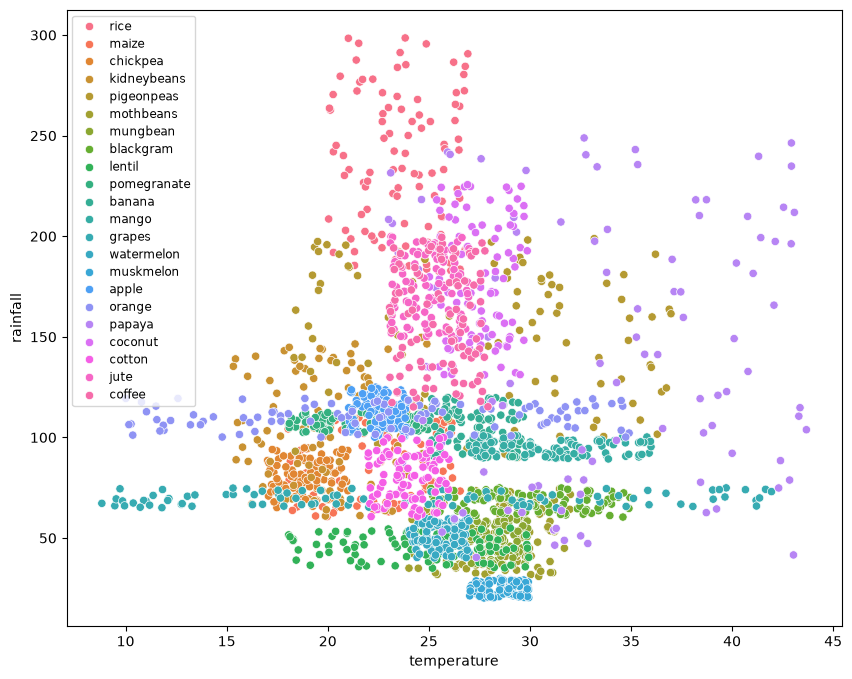

In [66]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=data, x='temperature', y='rainfall', hue='label')
plt.legend(fontsize="small", labelspacing=0.4, borderpad=0.4)
plt.show()

/tmp/ipykernel_34978/1794768169.py:3: UserWarning: 
The palette list has fewer values (20) than needed (22) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data, x = column, ax=axes[index//4, index%4], hue='label', palette=sns.color_palette("tab20", 20), legend=(index == 0))
/tmp/ipykernel_34978/1794768169.py:3: UserWarning: 
The palette list has fewer values (20) than needed (22) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data, x = column, ax=axes[index//4, index%4], hue='label', palette=sns.color_palette("tab20", 20), legend=(index == 0))
/tmp/ipykernel_34978/1794768169.py:3: UserWarning: 
The palette list has fewer values (20) than needed (22) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data, x = column, ax=axes[index//4, index%4], hue='label', palette=sns.color_palette("tab20", 20), legend=(index == 0))
/tmp/ipykernel_34978/1794768169.py:3: UserWarning: 
The palette list has fewer values (20) than n

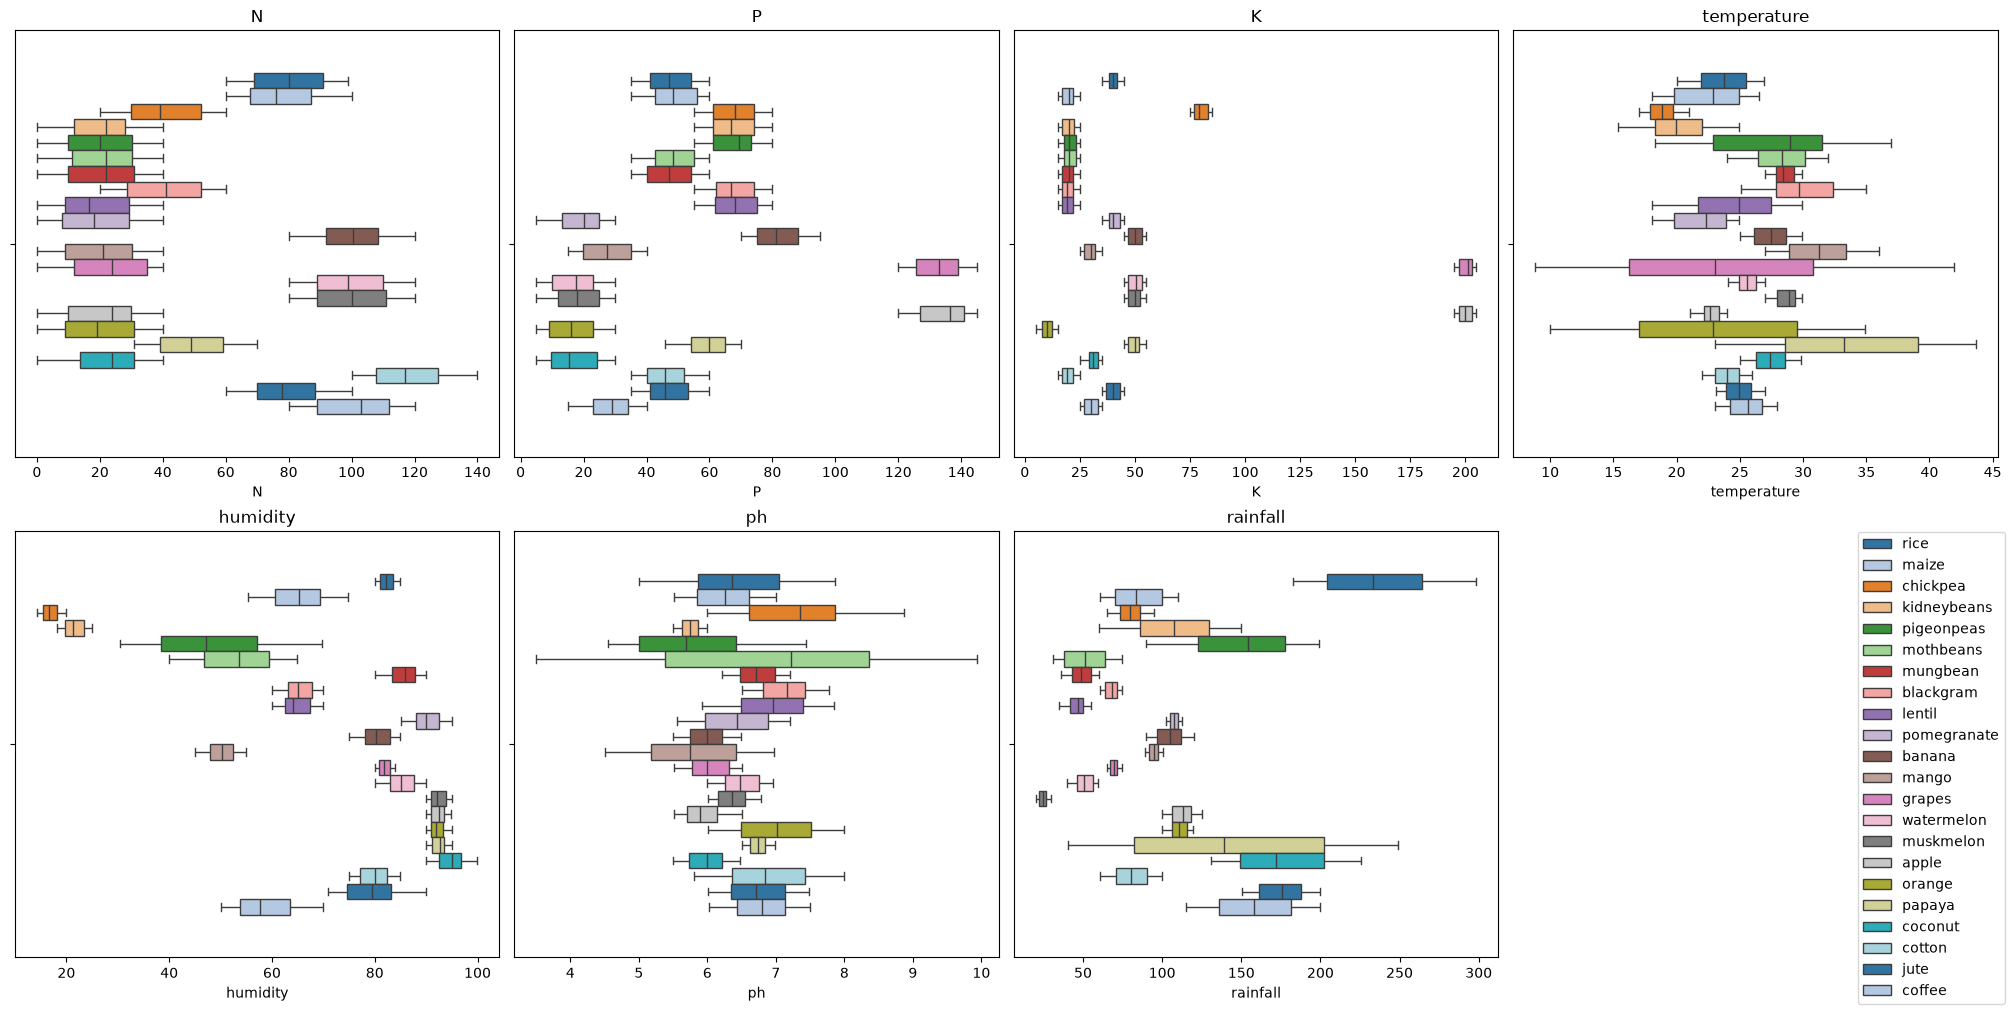

In [67]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
for index, column in enumerate(data.drop(columns=["label"]).columns):
    sns.boxplot(data, x = column, ax=axes[index//4, index%4], hue='label', palette=sns.color_palette("tab20", 20), legend=(index == 0))
    axes[index//4, index%4].set_title(column)
handles, labels = axes[0, 0].get_legend_handles_labels()

axes[1, 3].axis("off")
axes[0, 0].legend_.remove()
fig.legend(handles, labels, loc="lower right")

plt.show()

### Primer modelo simple

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [69]:
X = data.drop(columns=['label'])
y = data.label
X.shape, y.shape

((2200, 7), (2200,))

In [70]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

params = {
        "model__solver": ["saga"],
        "model__l1_ratio": [0, 0.3, 0.5, 0.7, 1],
        "model__max_iter": [100],
        "model__C": [1, 10, 100],
    }

In [ ]:
# primero splitear, luego scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [72]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.0687974 , -0.34455075, -0.1016875 , ...,  0.47266646,
         0.04330173,  1.8103605 ],
       [ 0.93332887,  0.14061552, -0.14118477, ...,  0.39705125,
         0.73487256,  2.24205791],
       [ 0.25598625,  0.04964684, -0.08193887, ...,  0.48695381,
         1.77151047,  2.92106603],
       ...,
       [ 1.82742114, -0.61745677, -0.35841972, ..., -0.19123516,
        -0.13812031,  1.27141766],
       [ 1.80032743, -0.64777967, -0.27942519, ..., -0.86951801,
         0.37390383,  0.43154519],
       [ 1.44810927, -1.07230015, -0.35841972, ..., -0.49802006,
         0.40109573,  0.68200518]], shape=(2200, 7))

In [73]:
from sklearn.metrics import classification_report
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

#mostrar resultados
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       0.95      1.00      0.98        21
   blackgram       0.83      0.75      0.79        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.80      0.94      0.86        17
      grapes       1.00      1.00      1.00        14
        jute       0.91      0.87      0.89        23
 kidneybeans       1.00      0.95      0.97        20
      lentil       0.83      0.91      0.87        11
       maize       0.94      0.76      0.84        21
       mango       0.95      1.00      0.97        19
   mothbeans       0.85      0.92      0.88        24
    mungbean       0.95      1.00      0.97        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       0.95    

/home/felipe/agri_dataset/crop/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [74]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_model.score(X_test, y_test)

/home/felipe/agri_dataset/crop/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9454545454545454

____
### Segundo modelo
